# Modelo Mono-modal: DSTFS Adaptado para Tarea Única

Este cuaderno implementa el entrenamiento y la evaluación del **DSTFS-adapted** (Deep Soft Threshold Feature Separation) adaptado exclusivamente para la tarea de regresión temporal en la disipación de huellas térmicas sobre superficies.

Incorpora el mecanismo de activación de **Umbral Suave PReLU (SPRelu)** para mitigar el ruido débil e inestable residual, y utiliza la función de pérdida robusta **SqrtScaledMSELoss** para amplificar el gradiente en las etapas iniciales de decaimiento rápido.

In [1]:
import sys
import random
from pathlib import Path

# Añadir el directorio raíz al path de Python para permitir importaciones correctas
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

from src.models.dstfs import ThermalDepartureTimeNet
from src.loaders.dstfs_loader import ThermalTraceDataset
from src.utils import SqrtScaledMSELoss, eval_dstfs_metrics, split_by_sequence, plot_learning_curves, plot_prediction_calibration, plot_error_by_time_window

### 1. Semilla Global y Reproducibilidad

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### 2. Configuración General (Hiperparámetros)

In [3]:
CONFIG = {
    "epochs": 120,
    "patience": 15,
    "min_delta": 1.0,
    "batch_size": 16,
    "lr": 0.0005,          # SGD lr inicial de 0.0005
    "weight_decay": 0.0005, # DSTFS: Regularización L2 de 0.0005
    "momentum": 0.9,       # SGD Momentum de 0.9
    "min_time_s": 0.0,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "time_scale": 30.0,
}

### 3. Instanciación del Dataset y Dataloaders

In [4]:
dev = CONFIG["device"]

# Los datasets esperan las rutas relativas al directorio principal
train_ds_full = ThermalTraceDataset(metadata_csv="../processed_data/metadata_train.csv", is_train=True, min_time_s=CONFIG["min_time_s"])
val_ds_full = ThermalTraceDataset(metadata_csv="../processed_data/metadata_train.csv", is_train=False, min_time_s=CONFIG["min_time_s"])

# Adaptamos la ruta raíz de los datasets para que apunte al directorio correcto en notebooks
train_ds_full.root = Path("../processed_data")
val_ds_full.root = Path("../processed_data")

t_idx, v_idx = split_by_sequence(train_ds_full.df)

train_loader = DataLoader(Subset(train_ds_full, t_idx), batch_size=CONFIG["batch_size"], shuffle=True, pin_memory=True)
val_loader = DataLoader(Subset(val_ds_full, v_idx), batch_size=CONFIG["batch_size"], pin_memory=True)
train_eval_loader = DataLoader(Subset(train_ds_full, t_idx), batch_size=CONFIG["batch_size"], pin_memory=True)

print(f"Datos cargados: {len(t_idx)} train / {len(v_idx)} val | Device: {dev}")

Datos cargados: 1111 train / 329 val | Device: cuda


### 4. Inicialización del Modelo, Pérdida y Optimización

In [5]:
model = ThermalDepartureTimeNet().to(dev)

# Inicializamos SqrtScaledMSELoss con el factor de escala requerido por el modelo mono-modal
crit = SqrtScaledMSELoss(scale=CONFIG["time_scale"])

opt = torch.optim.SGD(model.parameters(), lr=CONFIG["lr"], momentum=CONFIG["momentum"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)

print(f"Parámetros totales de DSTFS-adapted: {sum(p.numel() for p in model.parameters()):,}")

Parámetros totales de DSTFS-adapted: 11,570,769


### 5. Ciclo de Entrenamiento e Impresión de Métricas Unificadas

In [6]:
best_mae = float("inf")
no_imp = 0
history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}

for ep in range(1, CONFIG["epochs"] + 1):
    model.train()
    train_loss, n = 0.0, 0
    for x, y in train_loader:
        x, y = x.to(dev), y.to(dev)
        opt.zero_grad(set_to_none=True)
        loss = crit(model(x), y)
        loss.backward()
        opt.step()
        train_loss += loss.item() * x.size(0)
        n += x.size(0)

    scheduler.step()
    
    # Calcular pérdida de validación para el historial
    model.eval()
    val_loss = 0.0
    val_n = 0
    with torch.no_grad():
        for val_x, val_y in val_loader:
            val_x, val_y = val_x.to(dev), val_y.to(dev)
            loss = crit(model(val_x), val_y)
            val_loss += loss.item() * val_x.size(0)
            val_n += val_x.size(0)
    val_loss /= val_n

    # Evaluación unificada en segundos reales desescalados
    val_m = eval_dstfs_metrics(model, val_loader, dev)
    train_m = eval_dstfs_metrics(model, train_eval_loader, dev)

    v_mae = val_m["mae"]
    is_best = v_mae < best_mae - CONFIG["min_delta"]
    if is_best: 
        best_mae, no_imp = v_mae, 0
        torch.save(model.state_dict(), "../DSTFS_adapted_best.pt")
    else: 
        no_imp += 1
        
    # Guardar métricas en el historial
    history["train_loss"].append(train_loss / n)
    history["val_loss"].append(val_loss)
    history["train_mae"].append(train_m["mae"])
    history["val_mae"].append(v_mae)
    
    print(f"Ep {ep:03d} | Loss: {train_loss/n:.4f} | "
          f"TrMAE: {train_m['mae']:5.2f}s | ValMAE: {v_mae:5.2f}s | "
          f"RMSE: {val_m['rmse']:5.2f}s | R2: {val_m['r2']:.4f} | MAPE: {val_m['mape']:5.2f}% | "
          f"Acc60: {val_m['acc60']:.2f}% | Acc120: {val_m['acc120']:.2f}% {'*' if is_best else ''}")
    
    if no_imp >= CONFIG["patience"]:
        print(f"Early stop alcanzado. Mejor Val MAE: {best_mae:.2f}s")
        break

Ep 001 | Loss: 5.3128 | TrMAE: 190.18s | ValMAE: 196.06s | RMSE: 255.68s | R2: -1.4050 | MAPE: 100.47% | Acc60: 27.66% | Acc120: 40.43% *
Ep 002 | Loss: 3.6100 | TrMAE: 165.93s | ValMAE: 174.95s | RMSE: 233.32s | R2: -1.0027 | MAPE: 103.84% | Acc60: 30.09% | Acc120: 45.90% *
Ep 003 | Loss: 2.0999 | TrMAE: 129.38s | ValMAE: 141.73s | RMSE: 190.21s | R2: -0.3310 | MAPE: 75.93% | Acc60: 33.13% | Acc120: 54.41% *
Ep 004 | Loss: 1.1918 | TrMAE: 116.10s | ValMAE: 127.75s | RMSE: 169.60s | R2: -0.0582 | MAPE: 72.95% | Acc60: 33.43% | Acc120: 58.66% *
Ep 005 | Loss: 0.6975 | TrMAE: 94.09s | ValMAE: 96.68s | RMSE: 132.20s | R2: 0.3570 | MAPE: 64.13% | Acc60: 46.81% | Acc120: 72.64% *
Ep 006 | Loss: 0.4607 | TrMAE: 79.70s | ValMAE: 84.79s | RMSE: 114.75s | R2: 0.5155 | MAPE: 55.66% | Acc60: 48.33% | Acc120: 76.90% *
Ep 007 | Loss: 0.3509 | TrMAE: 61.50s | ValMAE: 65.64s | RMSE: 91.01s | R2: 0.6953 | MAPE: 51.89% | Acc60: 61.40% | Acc120: 85.41% *
Ep 008 | Loss: 0.2650 | TrMAE: 51.99s | ValMAE: 6

### 6. Visualización de Resultados Experimentales y Curvas de Aprendizaje

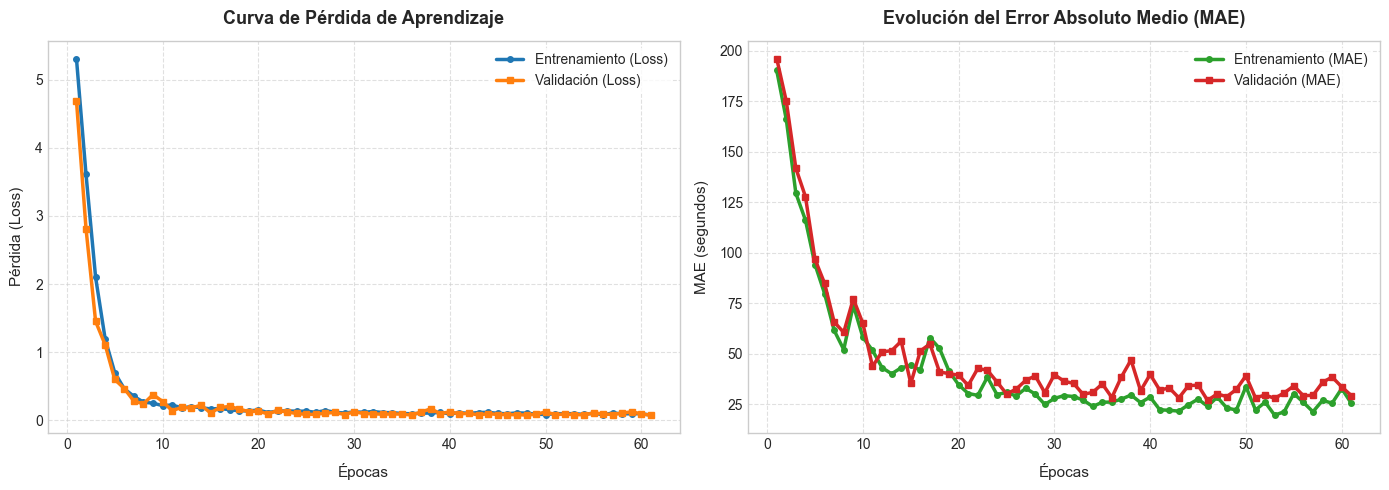

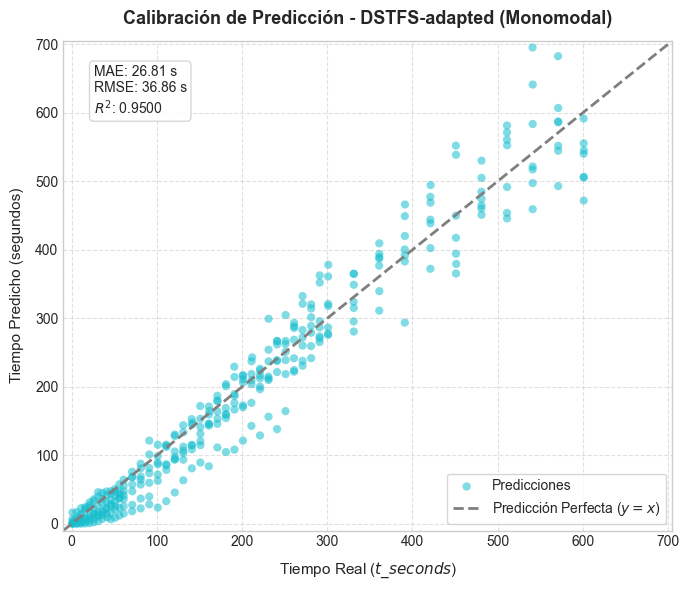

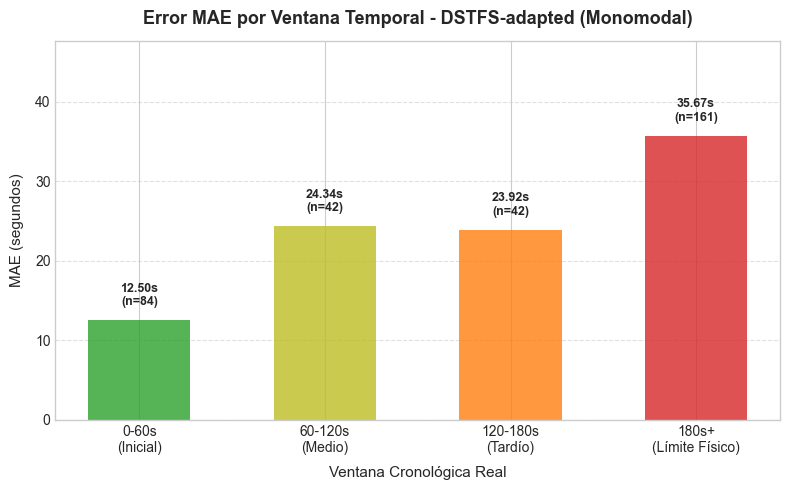

In [7]:
# 1. Graficar Curvas de Aprendizaje (Loss y MAE)
plot_learning_curves(history)

# 2. Cargar el mejor modelo guardado para la evaluación de calibración
model.load_state_dict(torch.load("../DSTFS_adapted_best.pt"))
model.eval()

# 3. Recolectar predicciones sobre el conjunto de validación completo
y_true_list = []
y_pred_list = []
with torch.no_grad():
    for x_batch, y_batch in val_loader:
        x_batch, y_batch = x_batch.to(dev), y_batch.to(dev)
        preds = model(x_batch)
        y_true_list.extend(y_batch.cpu().numpy().tolist())
        y_pred_list.extend(preds.cpu().numpy().tolist())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

# 4. Graficar Calibración y Distribución del Error por Ventana Temporal
plot_prediction_calibration(y_true, y_pred, model_name="DSTFS-adapted (Monomodal)")
plot_error_by_time_window(y_true, y_pred, model_name="DSTFS-adapted (Monomodal)")